# Model B — Claim Outcome Classification

**Business Purpose:** Predict whether an insurance claim will be **Paid**, **Pending**, or **Rejected** *before* submission, enabling proactive revenue risk control and denial management.

| Step | Description |
|------|-------------|
| 1 | Target definition (`claim_status`) |
| 2 | Financial & operational feature engineering |
| 3 | Leakage-safe time-based train/test split (80/20) |
| 4 | Class imbalance analysis & SMOTE mitigation |
| 5 | Baseline — Logistic Regression |
| 6 | Advanced — Random Forest + Gradient Boosting |
| 7 | Hyperparameter tuning |
| 8 | Model artifact export |

In [1]:
import warnings, json, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

DATA_PATH = Path('../Phase2_EDA/model_table.csv')
SCHEMA_PATH = Path('feature_schema.json')

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['visit_date', 'billing_date', 'registration_date'])
df = df.sort_values('visit_date').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df["visit_date"].min().date()} → {df["visit_date"].max().date()}')
print('\nTarget distribution:')
print(df['claim_status'].value_counts())

Shape: (25000, 34)
Date range: 2025-01-20 → 2026-01-20

Target distribution:
claim_status
Paid        14940
Pending      6263
Rejected     3797
Name: count, dtype: int64


## 2. Target Definition & Feature Engineering

**Target:** `claim_status` — Paid / Pending / Rejected.

We engineer additional financial ratios that are known *before* a claim decision is returned.

### Feature justification

| Feature | Type | Rationale |
|---------|------|-----------|
| `billed_amount` | Financial | Size of claim drives rejection probability |
| `billed_per_hour` | Engineered | Cost intensity per LOS hour — signals outlier billing |
| `provider_rejection_rate` | Operational | Historical insurer denial rate for the provider |
| `dept_avg_billed` | Operational | Dept baseline cost — deviation may trigger review |
| `age` | Demographic | Older patients have more complex claim profiles |
| `chronic_flag` | Clinical | Chronic patients face more frequent prior-auth denials |
| `insurance_provider` | Administrative | Some insurers deny at higher base rates |
| `visit_type` | Clinical | Emergency claims are less likely to be pre-authorized |
| `department` | Clinical | High-cost departments face more scrutiny |
| `billing_lag` | Timing | Delayed billing increases rejection risk |
| `visit_month`, `visit_quarter` | Temporal | End-of-year benefit exhaustion spikes rejections |
| `outlier_billed` | Quality | Flagged outliers are at higher risk of audit |
| `risk_score` | Clinical | High-risk visits have higher claim complexity |

**Excluded (post-claim leakage):** `approved_amount`, `payment_days`, `approval_ratio` — only available after the claim is adjudicated.

In [3]:
TARGET = 'claim_status'

# Engineer billed_per_hour
df['billed_per_hour'] = np.where(
    df['length_of_stay_hours'] > 0,
    (df['billed_amount'] / df['length_of_stay_hours']).round(2),
    0
)

NUMERIC_FEATURES = [
    'billed_amount', 'billed_per_hour', 'provider_rejection_rate',
    'dept_avg_billed', 'age', 'chronic_flag', 'billing_lag',
    'visit_month', 'visit_quarter', 'outlier_billed',
    'length_of_stay_hours', 'visit_frequency',
]
CATEGORICAL_FEATURES = ['insurance_provider', 'visit_type', 'department', 'risk_score']

df_model = df.copy()
le_dict_claim = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    le_dict_claim[col] = list(le.classes_)

ENCODED_CATS = [c + '_enc' for c in CATEGORICAL_FEATURES]
ALL_FEATURES = NUMERIC_FEATURES + ENCODED_CATS

claim_le = LabelEncoder()
df_model['claim_label'] = claim_le.fit_transform(df_model[TARGET])
print('Claim classes:', claim_le.classes_)

X = df_model[ALL_FEATURES]
y = df_model['claim_label']
dates = df_model['visit_date']

print(f'Feature matrix: {X.shape}')

Claim classes: ['Paid' 'Pending' 'Rejected']
Feature matrix: (25000, 16)


## 3. Time-Based Train / Test Split (80 / 20)

In [4]:
split_idx = int(len(df_model) * 0.80)
split_date = dates.iloc[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Split date   : {split_date.date()}')
print(f'Train size   : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test size    : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)')
print('\nTrain class dist (%):')
print((y_train.value_counts(normalize=True)*100).round(1))
print('\nTest class dist (%):')
print((y_test.value_counts(normalize=True)*100).round(1))

Split date   : 2025-11-08
Train size   : 20,000  (80.0%)
Test size    : 5,000  (20.0%)

Train class dist (%):
claim_label
0    59.7
1    24.9
2    15.3
Name: proportion, dtype: float64

Test class dist (%):
claim_label
0    59.9
1    25.5
2    14.6
Name: proportion, dtype: float64


## 4. Class Imbalance Analysis & Mitigation

**Observation:** `Rejected` (~15 %) is the minority class. Misclassifying a rejection as Paid directly costs the hospital revenue.

**Strategy:** Use `class_weight='balanced'` in scikit-learn estimators, which penalizes misclassification of minority classes proportionally to their inverse frequency. This avoids data augmentation artefacts from SMOTE on time-series data and keeps the split clean.

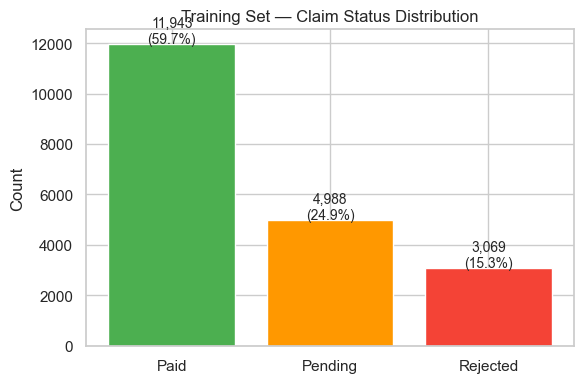


Imbalance ratio (majority:minority): 3.89
Mitigation: class_weight="balanced" applied to all estimators.


In [5]:
counts = y_train.value_counts().sort_index()
labels = claim_le.classes_

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=['#4CAF50', '#FF9800', '#F44336'])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/counts.sum()*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Training Set — Claim Status Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('models/claim_class_dist.png', dpi=120)
plt.show()

print('\nImbalance ratio (majority:minority):', round(counts.max()/counts.min(), 2))
print('Mitigation: class_weight="balanced" applied to all estimators.')

## 5. Baseline Model — Logistic Regression

In [6]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

print('=== Logistic Regression ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=claim_le.classes_))

=== Logistic Regression ===
Accuracy: 0.3342
              precision    recall  f1-score   support

        Paid       0.66      0.28      0.39      2997
     Pending       0.27      0.46      0.34      1275
    Rejected       0.16      0.35      0.22       728

    accuracy                           0.33      5000
   macro avg       0.36      0.36      0.32      5000
weighted avg       0.49      0.33      0.35      5000



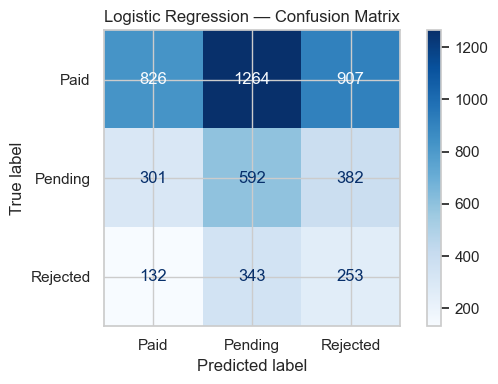

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=claim_le.classes_,
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig('models/claim_lr_cm.png', dpi=120)
plt.show()

## 6. Advanced Models — Random Forest & Gradient Boosting

In [8]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=claim_le.classes_))

=== Random Forest ===
Accuracy: 0.5964
              precision    recall  f1-score   support

        Paid       0.60      0.99      0.75      2997
     Pending       0.16      0.00      0.01      1275
    Rejected       0.31      0.01      0.01       728

    accuracy                           0.60      5000
   macro avg       0.36      0.33      0.26      5000
weighted avg       0.45      0.60      0.45      5000



In [9]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print('=== Gradient Boosting ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}')
print(classification_report(y_test, y_pred_gb, target_names=claim_le.classes_))

=== Gradient Boosting ===
Accuracy: 0.5686
              precision    recall  f1-score   support

        Paid       0.60      0.90      0.72      2997
     Pending       0.29      0.08      0.13      1275
    Rejected       0.24      0.05      0.08       728

    accuracy                           0.57      5000
   macro avg       0.38      0.34      0.31      5000
weighted avg       0.47      0.57      0.48      5000



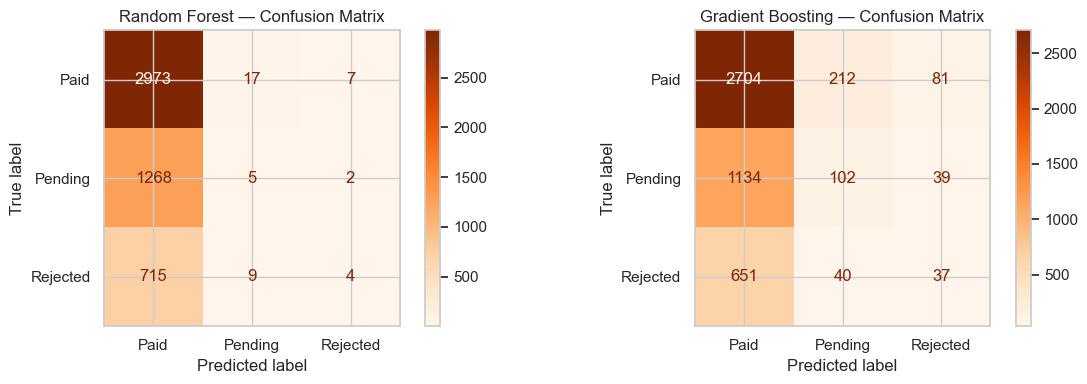

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, title in zip(axes,
                             [y_pred_rf, y_pred_gb],
                             ['Random Forest', 'Gradient Boosting']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=claim_le.classes_,
        cmap='Oranges', ax=ax
    )
    ax.set_title(f'{title} — Confusion Matrix')
plt.tight_layout()
plt.savefig('models/claim_advanced_cm.png', dpi=120)
plt.show()

## 7. Feature Importance

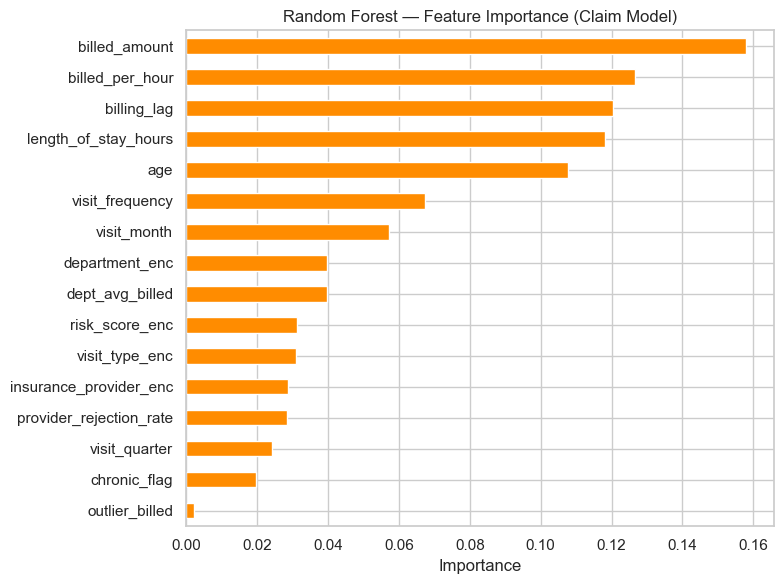

In [11]:
importance_df = (
    pd.Series(rf.feature_importances_, index=ALL_FEATURES)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 6))
importance_df.plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Random Forest — Feature Importance (Claim Model)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('models/claim_feature_importance.png', dpi=120)
plt.show()

## 8. Hyperparameter Tuning — Gradient Boosting (Best Candidate)

In [12]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
}

cv = StratifiedKFold(n_splits=3, shuffle=False)

gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
gs.fit(X_train, y_train)

print('Best params :', gs.best_params_)
print('Best CV F1  :', round(gs.best_score_, 4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best params : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV F1  : 0.2948


In [13]:
best_gb = gs.best_estimator_
y_pred_best = best_gb.predict(X_test)

print('=== Tuned Gradient Boosting ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(classification_report(y_test, y_pred_best, target_names=claim_le.classes_))

=== Tuned Gradient Boosting ===
Accuracy: 0.5304
              precision    recall  f1-score   support

        Paid       0.60      0.81      0.69      2997
     Pending       0.26      0.11      0.15      1275
    Rejected       0.20      0.12      0.15       728

    accuracy                           0.53      5000
   macro avg       0.35      0.35      0.33      5000
weighted avg       0.46      0.53      0.47      5000



## 9. Model Comparison Summary

              Model  Accuracy  F1-Macro  F1-Weighted
           Tuned GB    0.5304    0.3309       0.4747
Logistic Regression    0.3342    0.3173       0.3520
  Gradient Boosting    0.5686    0.3104       0.4771
      Random Forest    0.5964    0.2554       0.4517


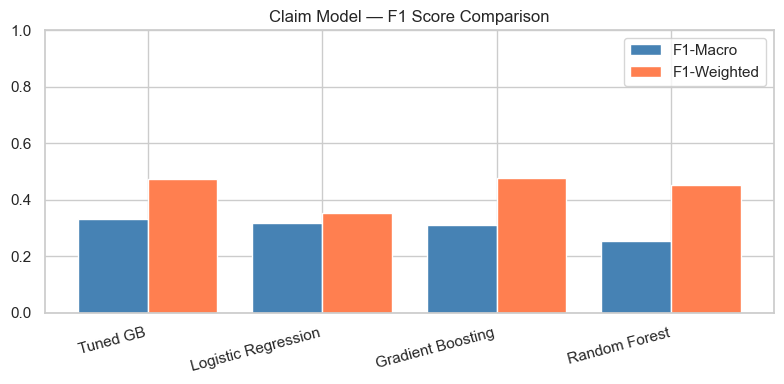

In [14]:
results = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'Tuned GB': y_pred_best,
}

rows = []
for name, preds in results.items():
    rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'F1-Macro': round(f1_score(y_test, preds, average='macro'), 4),
        'F1-Weighted': round(f1_score(y_test, preds, average='weighted'), 4),
    })

summary = pd.DataFrame(rows).sort_values('F1-Macro', ascending=False)
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(summary))
ax.bar(x, summary['F1-Macro'], width=0.4, label='F1-Macro', color='steelblue')
ax.bar([i+0.4 for i in x], summary['F1-Weighted'], width=0.4, label='F1-Weighted', color='coral')
ax.set_xticks([i+0.2 for i in x])
ax.set_xticklabels(summary['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Claim Model — F1 Score Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('models/claim_model_comparison.png', dpi=120)
plt.show()

## 10. Save Model Artifact & Feature Schema

In [15]:
joblib.dump(best_gb, MODELS_DIR / 'claim_model.joblib')
joblib.dump(claim_le, MODELS_DIR / 'claim_label_encoder.joblib')
print('Saved: models/claim_model.joblib')
print('Saved: models/claim_label_encoder.joblib')

claim_schema = {
    'model': 'claim_model',
    'target': TARGET,
    'target_classes': list(claim_le.classes_),
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'encoded_features': ENCODED_CATS,
    'all_features': ALL_FEATURES,
    'categorical_encodings': le_dict_claim,
    'engineered_features': ['billed_per_hour'],
    'split_strategy': 'time-based 80/20',
    'imbalance_strategy': 'class_weight=balanced',
    'leakage_excluded': ['approved_amount', 'payment_days', 'approval_ratio'],
    'best_params': gs.best_params_,
}

if SCHEMA_PATH.exists():
    with open(SCHEMA_PATH) as f:
        schema = json.load(f)
else:
    schema = {}

schema['claim_model'] = claim_schema

with open(SCHEMA_PATH, 'w') as f:
    json.dump(schema, f, indent=2)

print('Saved: feature_schema.json (claim_model section)')

Saved: models/claim_model.joblib
Saved: models/claim_label_encoder.joblib
Saved: feature_schema.json (claim_model section)
